### Загрузка данных

In [ ]:
from urllib.request import urlretrieve
import shutil
import pandas as pd
from pathlib import Path

#  Скачиваю данные
urlretrieve('https://storage.yandexcloud.net/datasouls-competitions/sirius/data.zip', 'data.zip')

# Распаковка архива
shutil.unpack_archive('data.zip', 'data')

#  Создание пути к директории `data`
data_directory = Path.cwd() / 'data'

#  Считывание файлов
df_target = pd.read_csv(data_directory / 'train_target.csv', sep=',')
df_transactions = pd.read_csv(data_directory / 'transactions_train.csv', sep=',')

#  Склейка двух таблиц по ключу `client_id`
df_merged = pd.merge(df_transactions, df_target, on='client_id', how='inner')

Свой анализ хотелось бы начать с простого, но интересного иследования.<br>
Хочется посмотреть сколько всего тратит денег каждая возрастная группа<br>
Я не нашел информацию по расшифровке возрастных групп, но это даже делает задачу интересней!<br>
Знаю, что в анализе данных по причине предвзятости так делать нельзя, но ДЗ, как я понял, больше на творчество и работу с визуализацией, поэтому<br>
поступлю креативно:<br>
1. Предположу, что возрастные группы были пронумерованы по порядку<br>
2. Дам им народные названия а именно:<br>
группа 0: 18-25лет - Зумеры<br>
группа 1: 26-42года - Миллениалы<br>
группа 2: 42-60года - Поколение X<br>
группа 3: 60+ - Бумеры<br>
3. Нарисую графики для подтверждения/опровержения своей теории.<br>

Первый график показывает сумму расходов каждой из групп<br>
А для тех, кто больше всех потратит, выводит информацию о том, на что их деньги уходят (по сумме расходов)<br>

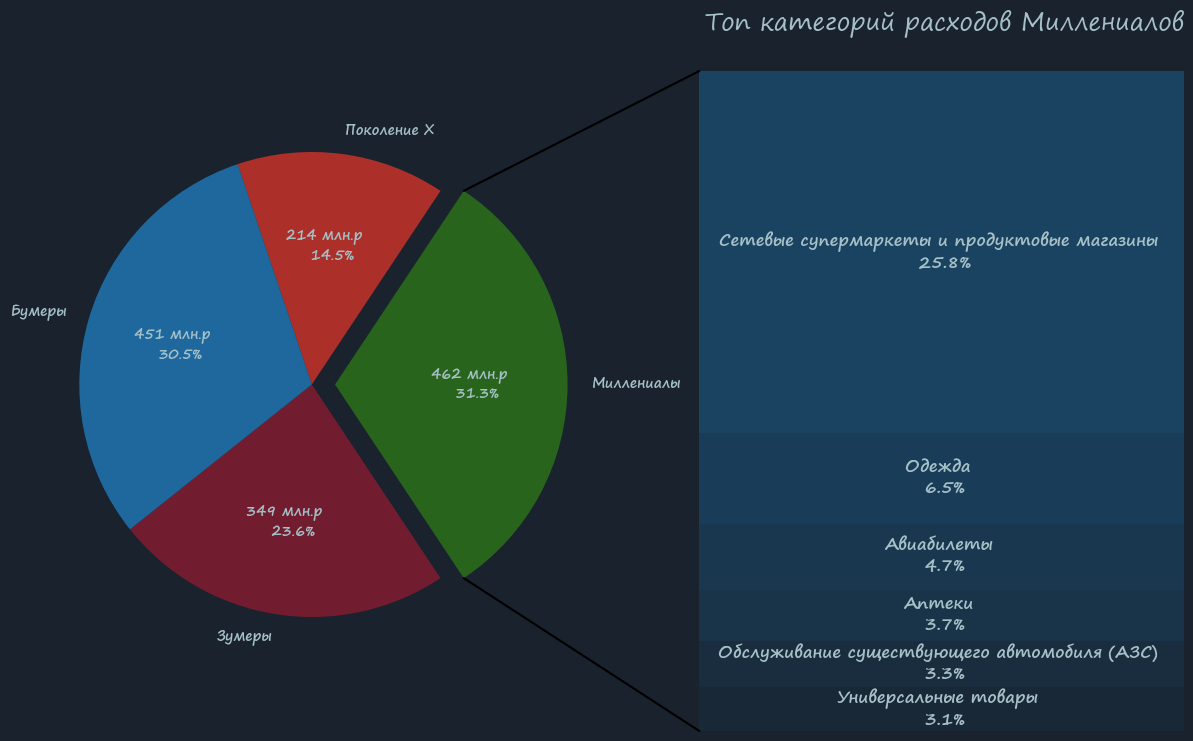

In [ ]:
from matplotlib.patches import ConnectionPatch

map_bin = {0: 'Зумеры', 1: 'Миллениалы', 2: 'Поколение X', 3: 'Бумеры'}

sum_group_bin_amount = df_merged.groupby('bins')['amount_rur'].sum()
max_value_index = np.argmax(sum_group_bin_amount)

w
def show_sum_and_percent(pct):
    total_sum = sum_group_bin_amount.sum()
    val = (pct / 100) * total_sum
    return f'{int(val // 1000_000)} млн.р  \n {pct:.1f}%'


explode_list = [0] * len(sum_group_bin_amount)
explode_list[max_value_index] = 0.1

overall_ratios = (sum_group_bin_amount / sum_group_bin_amount.sum()) * 360
angle = 0 - np.sum(overall_ratios[:max_value_index]) - (overall_ratios[max_value_index] / 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 9))
fig.subplots_adjust(wspace=0)
wedges, *_ = ax1.pie(sum_group_bin_amount,
                     autopct=show_sum_and_percent,
                     startangle=angle,
                     labels=sum_group_bin_amount.index.map(map_bin),
                     explode=explode_list,
                     colors=["#811c30da", "#2d741ad1", "#ce3429d1", "#1f76b4d8"]
                     )

target_data = df_merged[df_merged['bins'] == sum_group_bin_amount.index[max_value_index]]
#top_cat_count_buy = target_data['small_group'].value_counts()[:6]  Если нужно посмотреть количество транзакций вместо суммы
top_cat_count_buy = target_data.groupby('small_group')['amount_rur'].sum().sort_values(ascending=False)[:6]

total_in_bar = target_data['amount_rur'].sum()
transaction_ratios = (top_cat_count_buy.values / total_in_bar).tolist()

description = pd.read_csv(data_directory / 'small_group_description.csv', sep=',')
map_dict = description.set_index('small_group_code')['small_group'].to_dict()
transaction_labels = top_cat_count_buy.index.map(map_dict).tolist()

bar_height = sum(transaction_ratios)
bottom = bar_height
width = 8.0

for j, (height, label) in enumerate([*zip(transaction_ratios, transaction_labels)]):
    bottom -= height
    bc = ax2.bar(0, height, width, bottom=bottom, color="#1a4361", label=label,
                 alpha=1 - 0.16 * j)
    ax2.bar_label(bc, labels=[f'{label} \n {height:.1%}'], label_type='center', size='large')

ax2.set_title('Топ категорий расходов Миллениалов', size='xx-large', loc='right')
ax2.axis('off')
ax2.set_xlim(- 0.7 * width, 0.5 * width)

target_wedges = wedges[max_value_index]
theta1, theta2 = target_wedges.theta1, target_wedges.theta2
center, r = target_wedges.center, target_wedges.r

x = r * np.cos(np.pi / 180 * theta2) + center[0]
y = r * np.sin(np.pi / 180 * theta2) + center[1]
con = ConnectionPatch(xyA=(-width / 2, bar_height), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
con.set_linewidth(1.5)
ax2.add_artist(con)

x = r * np.cos(np.pi / 180 * theta1) + center[0]
y = r * np.sin(np.pi / 180 * theta1) + center[1]
con = ConnectionPatch(xyA=(-width / 2, 0), coordsA=ax2.transData,
                      xyB=(x, y), coordsB=ax1.transData)
con.set_color([0, 0, 0])
ax2.add_artist(con)
con.set_linewidth(1.5)

А говорят пенсионеры у нас плохо живут :) есть сомнения.. <br>
Хотя опять же возникает вопрос: а это данные из всей страны или Москвы? Очень важная информация в анализе.<br>
В остальном верю - расходы миллениалов вполне реальные, сам к ним отношусь и поесть я люблю :)

Посмотрим на что тратят другие группы

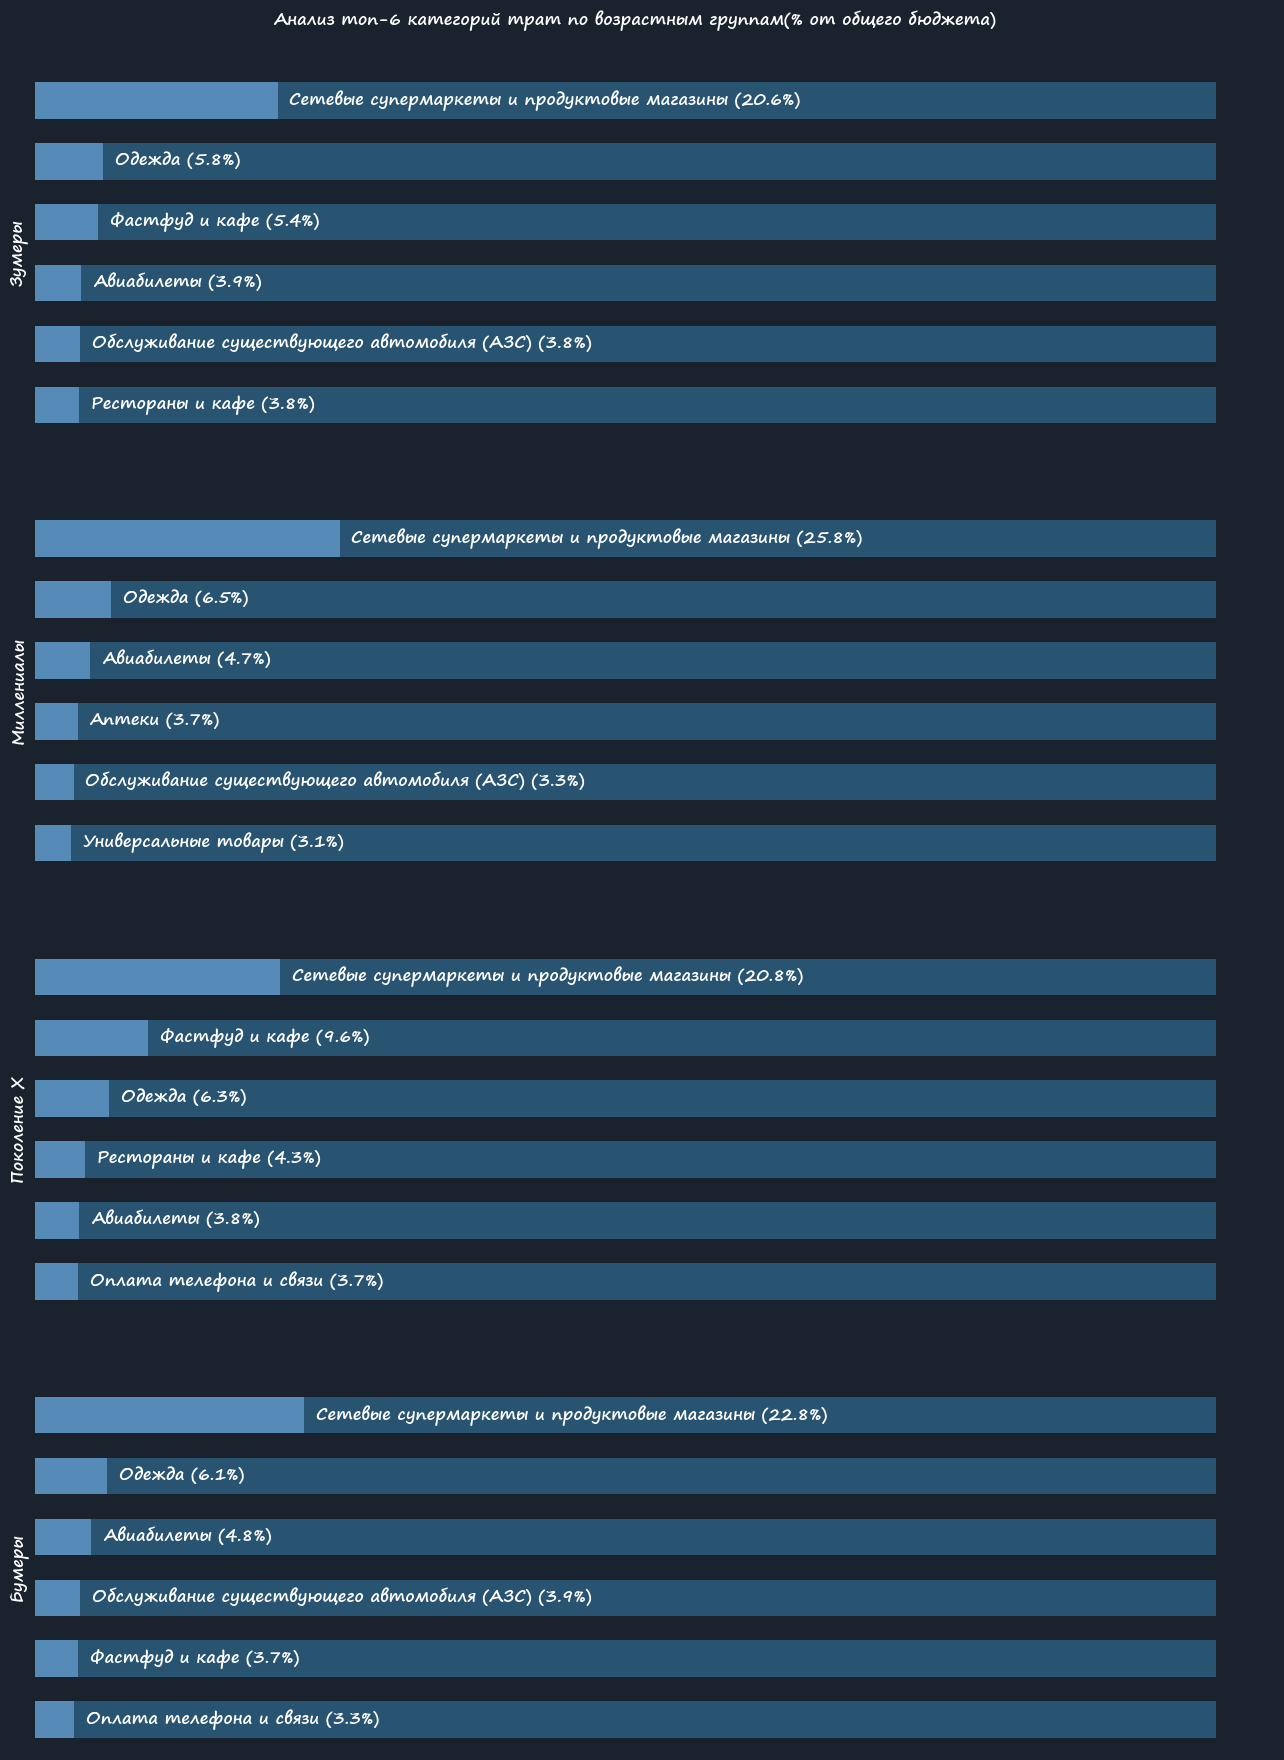

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(16, 20))
fig.subplots_adjust(wspace=0, top=0.95)
fig.suptitle('Анализ топ-6 категорий трат по возрастным группам(% от общего бюджета)', fontsize='large', color='white', fontweight='bold')

for i, ax_single in enumerate(ax.flatten()):
    bin_category_sum_sort = df_merged[df_merged['bins'] == i].groupby('small_group')['amount_rur'].sum().sort_values(ascending=False)
    current_bin_total_sum = bin_category_sum_sort.sum()
    top_6_df = bin_category_sum_sort[:6].reset_index()

    top_6_label = top_6_df['small_group'].map(map_dict).tolist()

    sns.barplot(
        x=current_bin_total_sum,
        y=top_6_label,
        width=0.6,
        ax=ax_single,
        edgecolor=None,
        color="#1c557db2"
     )

    sns.barplot(
        x='amount_rur',
        y=top_6_label,
        data=top_6_df,
        color="#478DC7C7",
        width=0.6,
        ax=ax_single
    )

    for x in range(6):
        bar = ax_single.patches[x + 6]
        x_pos = bar.get_width() + current_bin_total_sum * 0.01
        y_pos = bar.get_y() + bar.get_height() / 2

        current_amount = top_6_df.iloc[x]['amount_rur']
        percent=(current_amount / current_bin_total_sum) * 100

        label_text = f'{top_6_label[x]} ({percent:.1f}%)'

        ax_single.text(
            x_pos,
            y_pos,
            label_text,
            ha='left',
            va='center',
            fontsize='large',
            color='white'
        )

    ax_single.set_yticks([])
    ax_single.set_xticks([])
    ax_single.set_xlabel('')
    ax_single.set_ylabel(map_bin[i], fontsize='large', color='white')

    ax_single.spines['left'].set_visible(False)
    ax_single.spines['bottom'].set_visible(False)

Анализ графиков не полностью укладывается в мой жизненный кругозор:<br>
1. Зумеры:<br>
супермаркеты, одежда, кафе и фастфуд - 100% их тема<br>
а вот откуда у них деньги на путешествия и автомобили - это загадка,<br>
мои ожидания были Такси и каршеринг<br>
2. Cамая правдоподобная логика у Миллениалов:<br>
Появились аптеки (дети болеют и сами начинают следить за здоровьем)<br>
Авто и авиабилеты - показатели активной жизни и платежеспособности<br>
3. Поколение X:<br>
Я всегда считал, что они должны постоянно что-то строить,<br>
ремонтировать и что рассходы на дом, ремонт и  машину<br>
должны быть на первом месте. Аптеки тоже никто не отменял, ведь с возрастом<br>
сумма обычно только растет<br>
Но может быть я ошибаюсь! И люди в этом возрасте<br>
действительно расслабляются, много путешествуют и ходят по ресторанам<br>
забывая про всякие болячки. Очень надеюсь, что меня ждет такой же сценарий :)<br>
4. Бумеры:<br>
Что касается Бумеров (наших пенсионеров) мне как-то слабо верится, что они активно<br>
путешествуют, при этом совсем не тратясь на аптеки. Обычно их структура расходов<br>
немного другая.. хотя бы сад и огород :)

Ну все, анализ выполнен, закрываем лавочку?<br>
Вовсе нет.. я это так оставить не могу и просто обязан добавить пару капель профессионализма

Давайте посмотрим не затесалась ли в данных какая-нибудь "Блиновская",<br>
которая ломает статистику всего Сбербанка<br>
А если быть еще серьезней, то все расчеты действительно могут ломаться из-за больших<br>
выбросов, а также дисбаланса целевой метки, то есть в нашем случае возрастных групп<br>

Поэтому с чего на самом деле стоило начать, так это с построения графика бокс плот!

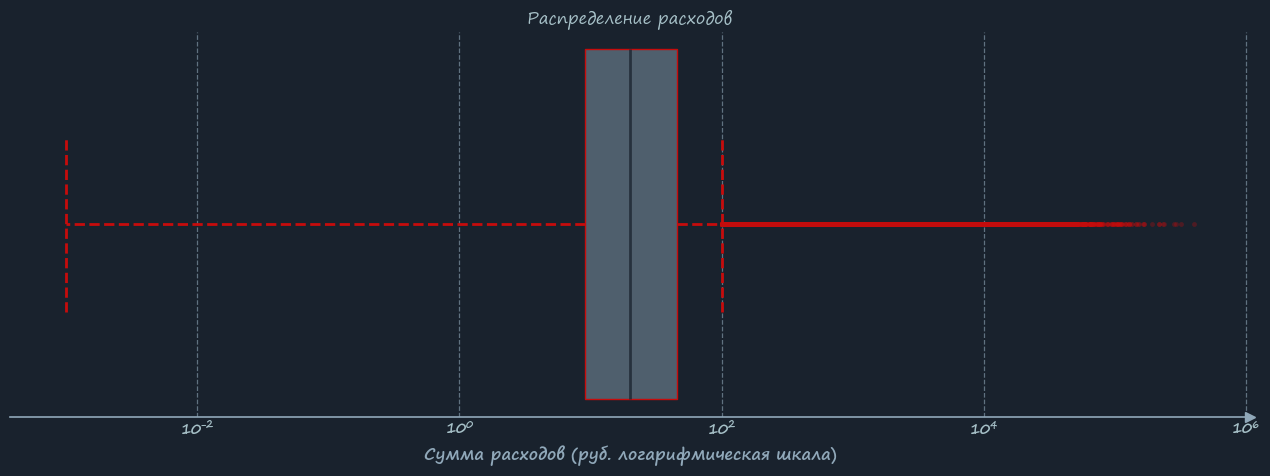

In [ ]:
fig, ax = plt.subplots(figsize=(16, 5))

flier_props = {
    'marker': '.',
    'markerfacecolor': '#c60c0c',
    'markersize': 7,
    'markeredgecolor': 'none',
    'alpha': 0.3
    }

boxprops = {
    'facecolor': "#90a8b975",
    'edgecolor': '#c60c0c'
    }

medianprops = {
    'color': "#19222dbe",
    'linewidth': 2
    }

whiskerprops = {
    'linestyle': '--',
    'linewidth': 2,
    'color': '#c60c0c'
    }

capprops = {
    'linestyle': '--',
    'linewidth': 2,
    'color': '#c60c0c'
    }

ax.boxplot(
    df_merged['amount_rur'],
    vert=False,
    widths=3,
    patch_artist=True,
    boxprops=boxprops,
    flierprops=flier_props,
    medianprops=medianprops,
    whiskerprops=whiskerprops,
    capprops=capprops
)

ax.set_xscale('log')
ax.set_yticks([])
ax.grid()

ax.spines['left'].set_visible(False)

ax.set_xlabel('Сумма расходов (руб. логарифмическая шкала)')
ax.set_title('Распределение расходов')

ax.plot(1, 0, ">", color='#90a8b9', transform=ax.transAxes, clip_on=False, markersize=7)

Придется выкинуть весь мой анализ выше в помойку, поскольку данный график подтвердил все опасения..<br>
Хотя, на самом деле, я увидел идеальную иллюстрацию закона распределения денег.<br>
50% всех операций, совершаемых покупок лежит в диапазоне от 100 до 1000 рублей -<br>
это все наши ежедневные покупки, те самые траты в магазинах, кафе, бытовые нужды<br>
Левый хвост это стандартные банковские копеечные корректировки<br>
А вот в правой части - зона дорогих покупок, сложно назвать это полноценными выбросами<br>
это очень значимая часть экономики, такие транзакции отбиваются от общей массы, но именно они составляют основной оборот денег


Так какой же график мне построить, чтобы пролить свет на главный вопрос задачи:<br>
"Скажи мне, на что ты тратишь деньги, и я скажу тебе, кто ты"?<br>
Без предобработки я бы однозначно выбрал матрицу корреляций, но не всю (всю к томуже колаб будет считать вечность), а только зависимости к возрасту.<br>

Text(0.5, 104.5833333333333, 'Бумеры')

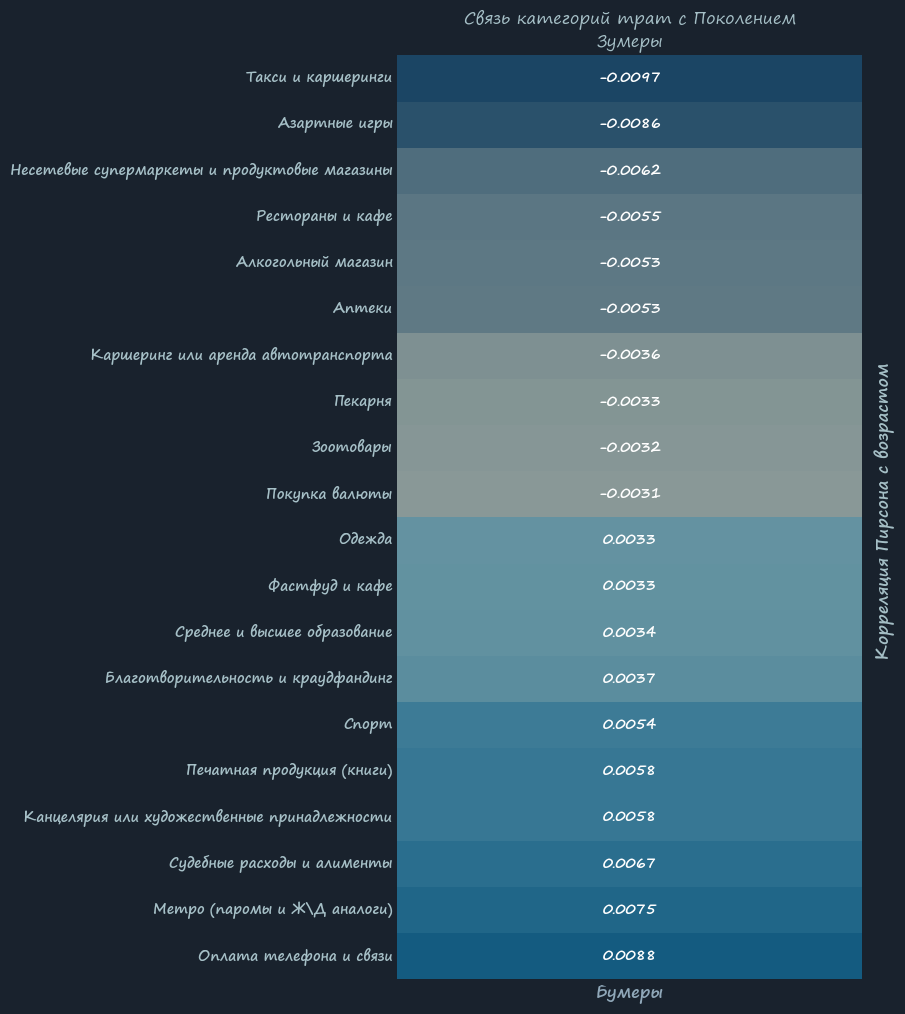

In [ ]:
from matplotlib import colors

analys = df_merged[['bins', 'small_group']].copy()
analys['small_group'] = analys['small_group'].map(map_dict)
analys_one_hot = pd.get_dummies(analys, columns=['small_group'], prefix='', prefix_sep='')

target = analys_one_hot['bins']
features = analys_one_hot.drop(columns=['bins'])

correlations = features.corrwith(target).sort_values()
correlations_df = correlations.to_frame(name='bins')

top_positive = correlations_df[:10]
top_negative = correlations_df[-10:]

final_corr_data = pd.concat([top_positive, top_negative])

fig, ax = plt.subplots(figsize=(6, 12))

my_cmap =colors.LinearSegmentedColormap.from_list('my_color', ["#1c557db2", "#cdcebaec", "#0ea2e673"])

sns.heatmap(final_corr_data,
            cmap=my_cmap,
            annot=True,
            annot_kws={'color': 'white'},
            cbar=False,
            ax=ax)

fig.text(
        0.92,
        0.5,
        'Корреляция Пирсона с возрастом',
        va='center',
        rotation=90,
        fontsize='large',
        color='#A6C0C7')

ax.set_title('Связь категорий трат с Поколением\nЗумеры')
ax.set_xticks([])
ax.set_xlabel('Бумеры')

А вот это уже более серьезное подтверждение моей теории, в которую можно поверить<br>
Кореляция, конечно, слабая, но она есть! да и не забываем, что это  лишь отдельно взятые признаки<br>
и тут важна не обсалютная цифра, а порядок сортировки!<br>

И так что мы теперь видим:<br>
Зумеры связаны с алкоголем, такси, кафе, и азартными играми.<br>
Пенсионеры часто ездят на поездах, читают книги и отжимают в суде квартиры :))<br>
Все сходится, этого я и ожидал.

А теперь внимание: самое главное, что я понял в мат. анализе, этого нет в учебниках!<br>
Самое главное, чтобы данные тебя не засосали и вовремя остановиться :)<br>
Что я сейчас и сделаю.<br>
Спасибо за внимание.<br>

Перед отправкой задания обязательно нажмите `Restart Kernel and Run All Cells`, чтобы убедиться, что весь код последовательно запускается без ошибок.